### Forward $NVT$ Simualtion with Lennard-Jones Potential
In this sample script, we demonstrate how to use JAX-MD to run a forward MD simulation with Lennard-Jones (LJ) potential. Through the script, we will showcase how to use $\psi_6$ order parameter to measure whether a hexagonal latttice has formed during the simulation.

#### 1. Imports and Utility Functions

In [1]:
import numpy as onp

from jax import config
config.update('jax_enable_x64', True)

import jax.numpy as jnp
from jax import random, jit, lax, vmap, jacfwd, remat
from jax.example_libraries import optimizers

import time
import os
from jax_md import space, smap, energy, minimize, quantity, simulate

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.collections import EllipseCollection
import seaborn as sns

sns.set_style(style='white')

def format_plot(x, y):
  plt.xlabel(x, fontsize=20)
  plt.ylabel(y, fontsize=20)

def finalize_plot(shape=(1, 1)):
  plt.gcf().set_size_inches(
    shape[0] * 1.5 * plt.gcf().get_size_inches()[1],
    shape[1] * 1.5 * plt.gcf().get_size_inches()[1],
  )
  plt.tight_layout()

#### 2. $\psi_k$ Order Parameter

In [2]:
def get_psi_k(displacement_all, k=6, r0=1.1, alpha=100):

  def weight(r):
    return jnp.where(r<1e-7, 0., 1.0/(1 + jnp.exp(alpha*(r - r0))))

  i_imaginary = complex(0,1)
  def get_ylms(dR_ij):
    epsilon = 0.00001 #avoids nan in derivative
    dR_ij = jnp.where(dR_ij==0.0, epsilon, dR_ij)
    theta = jnp.arctan2(dR_ij[1], dR_ij[0])
    return jnp.exp(i_imaginary*k*theta)

  def calculate_order_param(R):
    v_get_ylms = vmap(vmap(get_ylms))
    ds = displacement_all(R, R)
    r = space.distance(ds)
    w = weight(r)
    psi_k = (jnp.sum(v_get_ylms(ds)*w, axis=0)/(jnp.sum(w, axis=0)+0.00001))
    return psi_k

  def average_order_param(R):
    psi_k = calculate_order_param(R)
    return jnp.abs(jnp.mean(psi_k))

  return average_order_param

#### 3. General 2D Lattice Initialization

In [3]:
def make_2D_lattice_from_index_list(index_list,
                                    a0=jnp.array([jnp.sqrt(2),0.0]),
                                    a1=jnp.array([0.0,jnp.sqrt(2)]),
                                    unitcell=jnp.array([[0.0, 0.0]]),
                                    offset=jnp.array([0.0,0.0])):
  unitcell_particles = unitcell + offset 
  N = len(unitcell_particles)*index_list.shape[0]
  def get_cell(i,j):
    cell_shift = i*a0+j*a1
    return unitcell_particles + cell_shift

  return jnp.reshape(vmap(get_cell, in_axes=(0, 0))(index_list[:,0],index_list[:,1]),(N,2))

def make_2D_lattice(irange, jrange, **kwargs):
  index_list = jnp.array([ [i,j] for i in irange for j in jrange])
  return make_2D_lattice_from_index_list(index_list, **kwargs)

make_2D_lattice = jit(make_2D_lattice)

#### 4. Parameters for Simulation

In [7]:
### Global Parameters
M = 20
A = 1.5
A0_sq = jnp.array([A, 0])
A1_sq = jnp.array([0, A])
UNITCELL_sq = jnp.array([[0.0,0.0]])
N = M**2
DIMENSION = 2

RHO = 0.3
BOX_SIZE = (N/RHO)**(1/2)

kT = 0.2
dt = 1e-3
SIGMA = 1.0
R0 = 1.1

key=random.PRNGKey(22)

We will initialize our particles in a dilute square lattice.

In [8]:
R = (make_2D_lattice)(jnp.arange(0,M),jnp.arange(0,M),
                      a0 = A0_sq,
                      a1 = A1_sq,
                      unitcell= UNITCELL_sq,
                      offset=jnp.array([0.01, 0.03]))

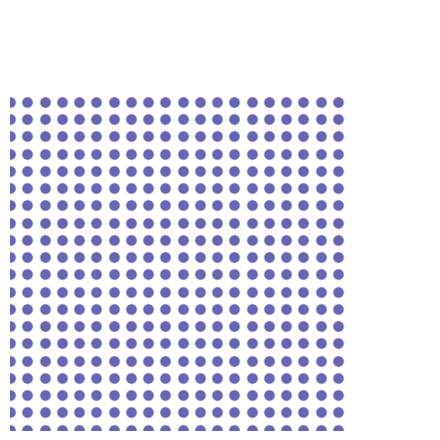

In [9]:
fig, ax = plt.subplots()
fig.set_size_inches(3, 3)
ax.add_collection(EllipseCollection(widths=SIGMA, heights=SIGMA, angles=0, units='xy',
                                       facecolors='navy', alpha = 0.6, 
                                       offsets=list(R), transOffset=ax.transData))
plt.xlim([0, BOX_SIZE])
plt.ylim([0, BOX_SIZE])
plt.axis('off')
finalize_plot((1, 1))

#### 5. Simulation Setup

In [10]:
displacement, shift = space.periodic(BOX_SIZE)
key, split = random.split(key)

energy_fn = energy.lennard_jones_pair(displacement, sigma = SIGMA)
init, apply = simulate.nvt_nose_hoover(energy_fn, shift, dt, kT = kT)
step = jit(lambda i, state: apply(state))
state = init(key, R)

displacement_all = vmap(vmap(displacement, (0, None), 0), (None, 0), 0)
order_param = get_psi_k(displacement_all, k=6, r0=R0, alpha=100)

PE = [energy_fn(state.position)]
KE = [quantity.kinetic_energy(momentum=state.momentum)]
P = [state.momentum]
T = [quantity.temperature(momentum=state.momentum)]
loss = [order_param(state.position)]
trajectory = [state.position]

N_steps = 1000
inner_steps = 100
print_every = 100
old_time = time.time()
print('Step\tKE\tPE\tTotal Energy\ttime/step')
print('----------------------------------------')

for i in range(N_steps):
  state = lax.fori_loop(0, inner_steps, step, state)

  PE += [energy_fn(state.position)]
  KE += [quantity.kinetic_energy(momentum=state.momentum)]
  P += [state.momentum]
  T += [quantity.temperature(momentum=state.momentum)]
  loss += [order_param(state.position)]
  trajectory += [state.position]

  if i % print_every == 0 and i > 0:
    new_time = time.time()
    print(
      '{}\t{:.2f}\t{:.2f}\t{:.3f}\t{:.2f}'.format(
        i * inner_steps,
        KE[-1],
        PE[-1],
        KE[-1] + PE[-1],
        (new_time - old_time) / print_every / inner_steps,
      )
    )
    old_time = new_time

PE = jnp.array(PE)
KE = jnp.array(KE)
P = jnp.array(P)
T = jnp.array(T)
loss = jnp.array(loss)
trajectory = jnp.array(trajectory)
R = state.position

Step	KE	PE	Total Energy	time/step
----------------------------------------
10000	79.11	-892.69	-813.580	0.00
20000	76.96	-956.35	-879.389	0.00
30000	76.84	-1029.80	-952.963	0.00
40000	72.45	-1062.07	-989.615	0.00
50000	83.69	-1086.12	-1002.429	0.00
60000	77.27	-1083.62	-1006.347	0.00
70000	81.57	-1076.21	-994.633	0.00
80000	79.25	-1083.67	-1004.417	0.00
90000	79.96	-1086.92	-1006.953	0.00


#### 6. Plot All Measured Quantities

<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_952895/1343369567.py:17: SyntaxWarning: invalid escape sequence '\p'
  axs[2].set_ylabel('$\psi_6$', fontsize = 18)


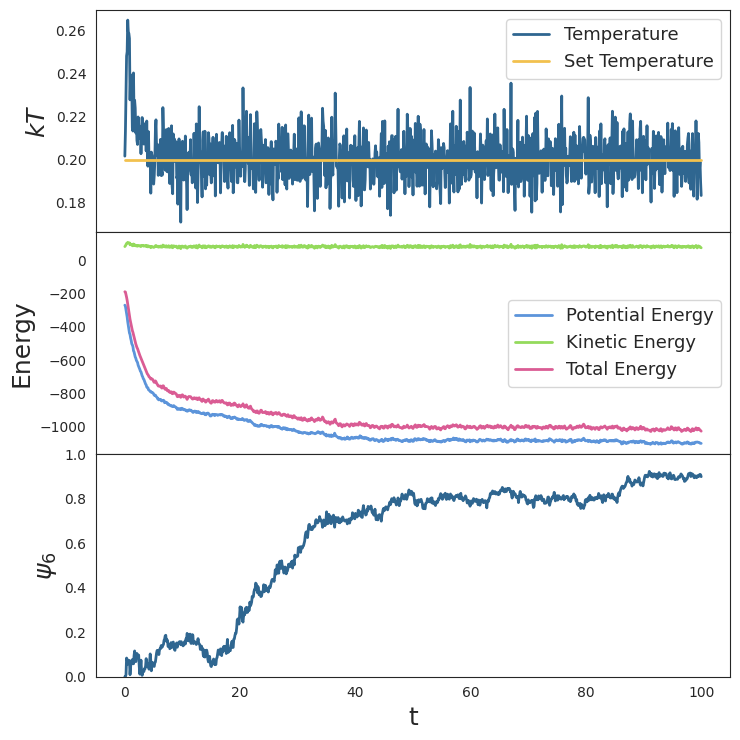

In [11]:
t = onp.arange(0, N_steps+1) * dt * inner_steps

fig = plt.figure(figsize = (8, 5))
gs = fig.add_gridspec(3, hspace=0)
axs = gs.subplots(sharex=True)

axs[0].plot(t, T, label = 'Temperature', color = '#2f6690', linewidth = 2)
axs[0].plot(t, onp.ones(len(t))*0.2, color = '#f2c14e', label = 'Set Temperature', linewidth = 2)
axs[0].legend(fontsize = 13)
axs[0].set_ylabel('$kT$', fontsize = 18)
axs[1].plot(t, PE, label='Potential Energy', color = '#5c94da', linewidth = 2)
axs[1].plot(t, KE, label='Kinetic Energy', color = '#94da5c', linewidth = 2)
axs[1].plot(t, PE + KE, label='Total Energy', color = '#da5c94', linewidth = 2)
axs[1].legend(fontsize = 13)
axs[1].set_ylabel('Energy', fontsize = 18)
axs[2].plot(t, loss, color = '#2f6690', linewidth = 2)
axs[2].set_ylabel('$\psi_6$', fontsize = 18)
axs[2].set_ylim(0.0, 1.0)
axs[2].set_xlabel('t', fontsize = 18)
finalize_plot()

#### 7. Simulation Snapshots

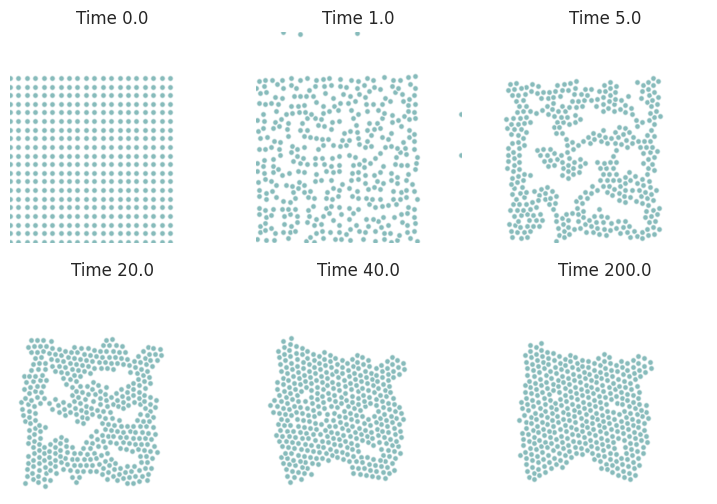

In [12]:
fig, axs = plt.subplots(2, 3)
fig.set_size_inches(9, 6)
index = [0, 10, 50, 200, 400, 2000]
for i in range(2):
  for j in range(3):
    axs[i, j].add_collection(EllipseCollection(widths=SIGMA, heights=SIGMA, angles=0, units='xy',
                             facecolors='#378e8e', alpha = 0.6, 
                             offsets=list(trajectory[index[i*3+j], :, :]), transOffset=axs[i, j].transData))
    axs[i, j].set_axis_off()
    axs[i, j].set_xlim([0, BOX_SIZE])
    axs[i, j].set_ylim([0, BOX_SIZE])
    axs[i, j].set_title("Time "+str(index[i*3+j]*dt*inner_steps))